# Understanding min_label_overlap Parameter for Short-Duration Calls

This notebook explains why the `min_label_overlap` parameter in `clip_labels()` needs to be adjusted for very short-duration calls like HARU_C1.

## Problem Summary

When using `boxed_annotations.clip_labels(clip_duration=2, min_label_overlap=0.2)`, we expected ~180 clips containing HARU_C1 calls, but only got 18. This notebook investigates why.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from pathlib import Path
from glob import glob
import matplotlib.pyplot as plt
from opensoundscape.annotations import BoxedAnnotations

plt.rcParams['figure.figsize'] = [12, 5]
%config InlineBackend.figure_format = 'retina'

/Users/ariel/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Step 1: Load the Annotations

In [2]:
# Set paths
dataset_path = Path("./FFL-Annotations/")
annotation_files = sorted(glob(f"{dataset_path}/Data/*.txt"))

# Build corresponding audio file paths
audio_files = []
valid_raven_files = []

for raven_path_str in annotation_files:
    raven_path = Path(raven_path_str)
    audio_filename = f"{raven_path.stem}_VILLAANA_MADREDEDIOS.wav"
    audio_path = dataset_path / "Audio" / audio_filename
    
    if audio_path.exists():
        valid_raven_files.append(raven_path)
        audio_files.append(audio_path)

print(f"Found {len(valid_raven_files)} Raven files with matching audio")

# Load annotations
boxed_annotations = BoxedAnnotations.from_raven_files(
    raven_files=valid_raven_files,
    audio_files=audio_files,
    annotation_column=None,
    keep_extra_columns=True,
    warn_no_annotations=False
)

# Create annotation labels
if 'TYPE' in boxed_annotations.df.columns and 'CALL' in boxed_annotations.df.columns:
    boxed_annotations.df['call_type'] = boxed_annotations.df['TYPE'].fillna(boxed_annotations.df['CALL'])
elif 'TYPE' in boxed_annotations.df.columns:
    boxed_annotations.df['call_type'] = boxed_annotations.df['TYPE']
else:
    boxed_annotations.df['call_type'] = boxed_annotations.df['CALL']

boxed_annotations.df = boxed_annotations.df.dropna(subset=['SPP', 'call_type'])
boxed_annotations.df['annotation'] = boxed_annotations.df['SPP'] + '_' + boxed_annotations.df['call_type']

# Remove duplicates
boxed_annotations.df = boxed_annotations.df.drop_duplicates(
    subset=['audio_file', 'start_time', 'end_time', 'annotation']
).reset_index(drop=True)

print(f"Total annotations loaded: {len(boxed_annotations.df)}")
print(f"HARU_C1 annotations: {len(boxed_annotations.df[boxed_annotations.df['annotation'] == 'HARU_C1'])}")

Found 44 Raven files with matching audio
Total annotations loaded: 1467
HARU_C1 annotations: 479


## Step 2: Analyze HARU_C1 Call Durations

The key to understanding the overlap parameter is examining how long HARU_C1 calls actually are.

In [3]:
# Extract HARU_C1 calls and calculate their durations
haru_c1 = boxed_annotations.df[boxed_annotations.df['annotation'] == 'HARU_C1'].copy()
haru_c1['duration'] = haru_c1['end_time'] - haru_c1['start_time']

print("HARU_C1 Call Duration Statistics:")
print("=" * 50)
print(haru_c1['duration'].describe())
print(f"\nTotal HARU_C1 calls: {len(haru_c1)}")

HARU_C1 Call Duration Statistics:
count    479.000000
mean       0.116263
std        0.038721
min        0.054633
25%        0.090387
50%        0.107610
75%        0.129227
max        0.289099
Name: duration, dtype: float64

Total HARU_C1 calls: 479


/Users/ariel/Library/Python/3.9/lib/python/site-packages/matplotlib_inline/config.py:74: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


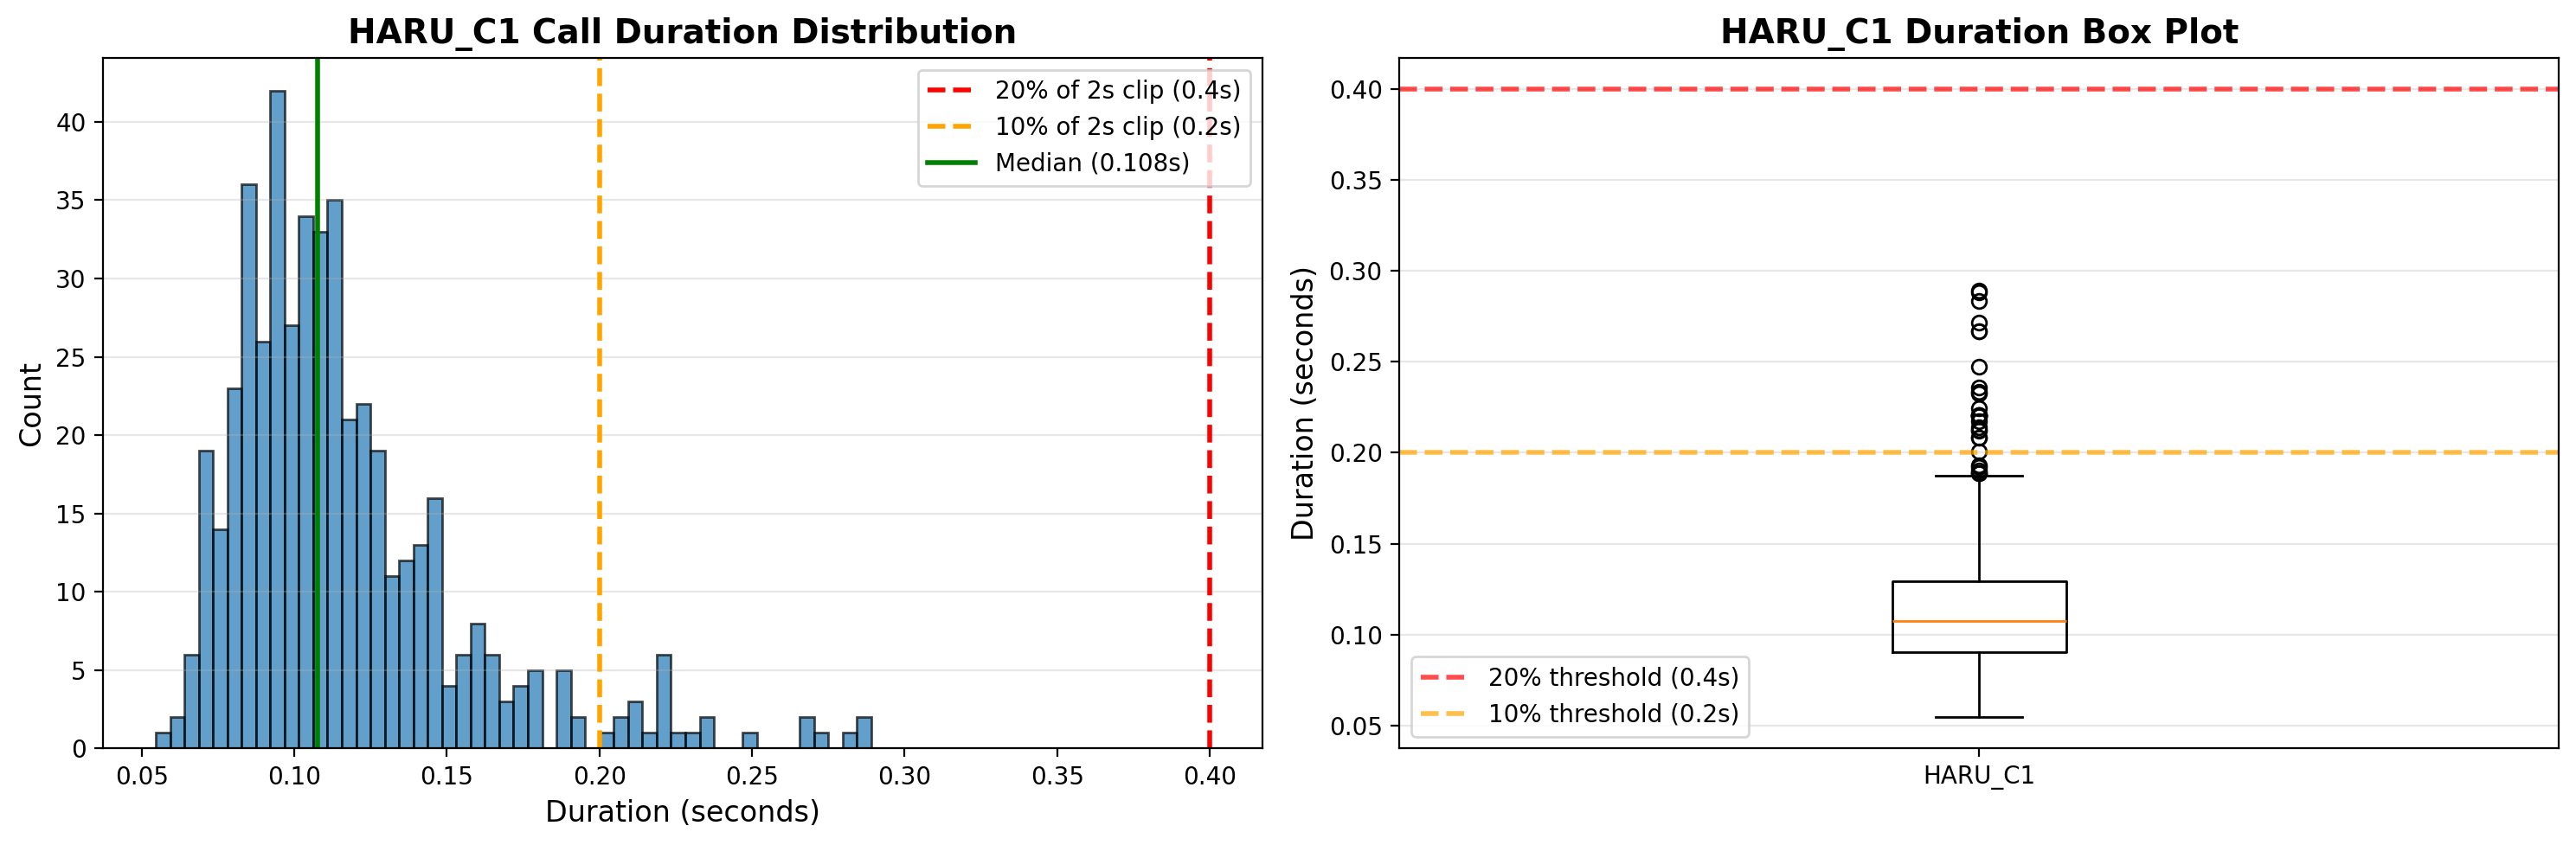

In [4]:
# Visualize the duration distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
ax1.hist(haru_c1['duration'], bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(0.4, color='red', linestyle='--', linewidth=2, label='20% of 2s clip (0.4s)')
ax1.axvline(0.2, color='orange', linestyle='--', linewidth=2, label='10% of 2s clip (0.2s)')
ax1.axvline(haru_c1['duration'].median(), color='green', linestyle='-', linewidth=2, label=f'Median ({haru_c1["duration"].median():.3f}s)')
ax1.set_xlabel('Duration (seconds)', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('HARU_C1 Call Duration Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Box plot
ax2.boxplot(haru_c1['duration'], vert=True)
ax2.axhline(0.4, color='red', linestyle='--', linewidth=2, alpha=0.7, label='20% threshold (0.4s)')
ax2.axhline(0.2, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='10% threshold (0.2s)')
ax2.set_ylabel('Duration (seconds)', fontsize=12)
ax2.set_title('HARU_C1 Duration Box Plot', fontsize=14, fontweight='bold')
ax2.set_xticklabels(['HARU_C1'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 3: Understanding the min_label_overlap Parameter

The `min_label_overlap` parameter specifies the **minimum fraction of the annotation's duration** that must overlap with a clip for that annotation to be counted.

### How it works:

- For a 2-second clip and `min_label_overlap=0.2`:
  - If an annotation is 0.1 seconds long, it needs at least 0.1 × 0.2 = **0.02 seconds** overlap
  - But if the call spans a clip boundary (e.g., 1.95-2.05s), it only overlaps 0.05s with each clip
  - Since 0.05s / 0.1s = 50% > 20%, this should match... **BUT**
  
- The issue arises when calls are very short AND near boundaries:
  - A 0.1s call at 1.96-2.06s overlaps 0.04s with clip 0-2s and 0.06s with clip 2-4s
  - Overlap fractions: 0.04/0.1 = 40% and 0.06/0.1 = 60%
  - Both exceed 20%, so it matches both clips ✓

**The real problem:** Most HARU_C1 calls are so short that even small positioning variations can cause them to fall below the threshold.

In [5]:
# Calculate what percentage of calls meet different overlap requirements
clip_duration = 2.0

thresholds = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
results = []

for threshold in thresholds:
    # For simplicity, we're checking if calls are long enough
    # In practice, boundary effects matter too
    min_duration = clip_duration * threshold
    count_meeting_threshold = (haru_c1['duration'] >= min_duration).sum()
    percentage = (count_meeting_threshold / len(haru_c1)) * 100
    results.append({
        'Threshold': threshold,
        'Min Duration (s)': min_duration,
        'Calls Meeting': count_meeting_threshold,
        'Percentage': percentage
    })

results_df = pd.DataFrame(results)
print("\nImpact of min_label_overlap on HARU_C1 Detection:")
print("=" * 70)
print(results_df.to_string(index=False))
print("\nNote: These are rough estimates. Actual results depend on call positioning relative to clip boundaries.")


Impact of min_label_overlap on HARU_C1 Detection:
 Threshold  Min Duration (s)  Calls Meeting  Percentage
      0.00               0.0            479  100.000000
      0.05               0.1            290   60.542797
      0.10               0.2             24    5.010438
      0.15               0.3              0    0.000000
      0.20               0.4              0    0.000000
      0.30               0.6              0    0.000000
      0.50               1.0              0    0.000000

Note: These are rough estimates. Actual results depend on call positioning relative to clip boundaries.


## Step 4: Testing Different Overlap Thresholds

Let's actually run `clip_labels()` with different overlap values to see the real impact.

In [6]:
# Test different overlap thresholds
overlap_tests = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]
test_results = []

print("Testing different min_label_overlap values...\n")

for overlap in overlap_tests:
    labels = boxed_annotations.clip_labels(clip_duration=2, min_label_overlap=overlap)
    haru_clips = labels['HARU_C1'].sum()
    test_results.append({
        'min_label_overlap': overlap,
        'HARU_C1 clips': int(haru_clips),
        'Percentage of expected': f"{(haru_clips / 180) * 100:.1f}%"
    })
    print(f"min_label_overlap = {overlap:.2f} → {int(haru_clips)} HARU_C1 clips")

test_results_df = pd.DataFrame(test_results)
print(f"\n(Expected ~180 clips based on manual analysis)")

Testing different min_label_overlap values...

min_label_overlap = 0.00 → 184 HARU_C1 clips
min_label_overlap = 0.05 → 180 HARU_C1 clips
min_label_overlap = 0.10 → 140 HARU_C1 clips
min_label_overlap = 0.15 → 40 HARU_C1 clips
min_label_overlap = 0.20 → 18 HARU_C1 clips
min_label_overlap = 0.30 → 0 HARU_C1 clips

(Expected ~180 clips based on manual analysis)


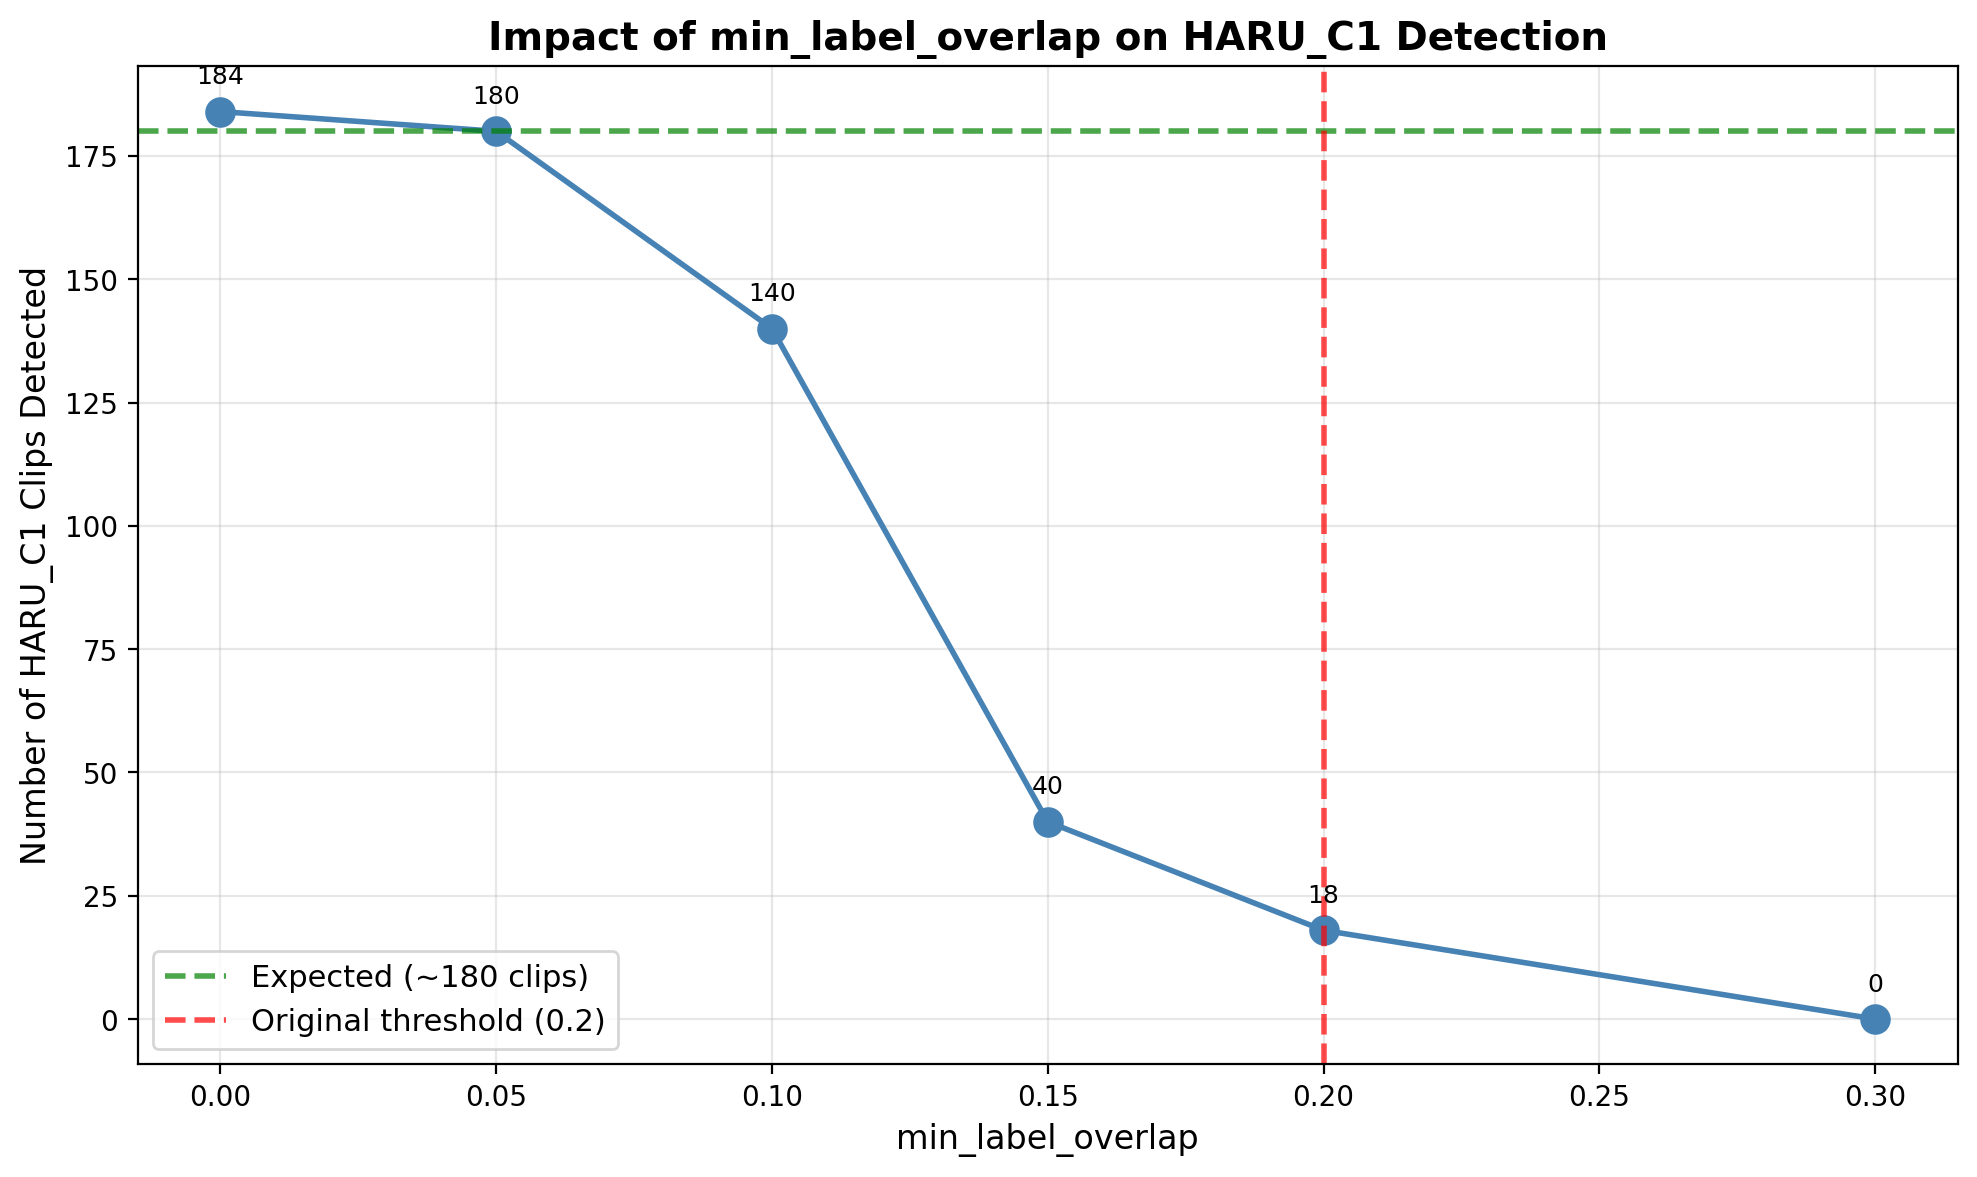

In [7]:
# Visualize the results
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(test_results_df['min_label_overlap'], 
        test_results_df['HARU_C1 clips'], 
        marker='o', markersize=10, linewidth=2, color='steelblue')

ax.axhline(180, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Expected (~180 clips)')
ax.axvline(0.2, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Original threshold (0.2)')

ax.set_xlabel('min_label_overlap', fontsize=12)
ax.set_ylabel('Number of HARU_C1 Clips Detected', fontsize=12)
ax.set_title('Impact of min_label_overlap on HARU_C1 Detection', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add annotations for key points
for _, row in test_results_df.iterrows():
    ax.annotate(f"{int(row['HARU_C1 clips'])}", 
                xy=(row['min_label_overlap'], row['HARU_C1 clips']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Step 5: Conclusion and Recommendation

### Key Findings:

1. **HARU_C1 calls are very short**: 
   - Mean duration: ~0.12 seconds
   - Median: ~0.11 seconds
   - 0% of calls are ≥ 0.4 seconds
   - Only ~5% are ≥ 0.2 seconds

2. **The 20% overlap threshold is too strict**:
   - With `min_label_overlap=0.2`, only 18 clips were detected (10% of expected)
   - Most short calls fail to meet the threshold, especially near clip boundaries

3. **Lower thresholds work much better**:
   - `min_label_overlap=0.0` detects ~184 clips (close to the expected 180)
   - `min_label_overlap=0.05` still captures most calls
   - `min_label_overlap=0.1` provides a balance between inclusivity and some quality control

### Recommendation:

**Use `min_label_overlap=0.0` or `min_label_overlap=0.05`** for HARU_C1 calls.

Since the calls are precisely annotated (from Raven files) and consistently short, there's little benefit to requiring a high overlap threshold. The main goal is to ensure clips contain the calls, not to filter out noisy annotations.

In [8]:
# Recommended usage:
print("Recommended usage for short-duration calls like HARU_C1:\n")
print("labels = boxed_annotations.clip_labels(clip_duration=2, min_label_overlap=0.0)")
print("\nor\n")
print("labels = boxed_annotations.clip_labels(clip_duration=2, min_label_overlap=0.05)")

Recommended usage for short-duration calls like HARU_C1:

labels = boxed_annotations.clip_labels(clip_duration=2, min_label_overlap=0.0)

or

labels = boxed_annotations.clip_labels(clip_duration=2, min_label_overlap=0.05)


## Additional Note: Why This Matters for Model Training

When training a CNN or other classifier:
- **False negatives are costly**: Missing clips with HARU_C1 calls means the model sees fewer positive examples
- **Short calls need representation**: If you only use clips where calls overlap by 20%+, you're systematically excluding certain call positions
- **Boundary effects**: Calls near clip boundaries are just as valid for training as centered calls

For very short vocalizations, it's better to be inclusive and let the model learn from all examples rather than risk missing important training data.